In [34]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from scipy import stats
import utils
import seaborn as sns
import pingouin as pg
import matplotlib.cm as cm

import statsmodels.stats.power as smp
from statsmodels.stats.anova import AnovaRM
from tqdm import tqdm


from natsort import index_natsorted

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.family'] = 'Calibri'

path_figs = "./Figs/"

fingers = ['1', '2', '3', '4', '5']

iti = 1000 # msecs for inter-trial interval
planTime = 2000 # msecs for precue time
feedbackTime = 2000 # msecs for feedback time


total_sub_num = 20
num_sessions = 1
num_blocks_per_session = 20
num_trials_per_block = 40

# sub_nums = [1,2]
sub_nums = [1,2]

utils.set_figure_style("1col")
sns.color_palette('colorblind')


[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [35]:
subjs = pd.read_csv(utils.path_misc+'subjs.csv', sep = '\t')

subjs = subjs[subjs['subNum'].isin(sub_nums)].reset_index(drop=True)


In [36]:
subjs.columns

Index(['subNum', 'BN', 'TN', 'TotalTrialNum', 'chord', 'targetVisible',
       'forceGain', 'targetForce', 'endForce', 'actualEndForce', 'trialCorr',
       'trialErrorType', 'day'],
      dtype='str')

In [37]:
subjs_correct = utils.remove_error_trials(subjs).copy()

BN: 1, Target Force: -3.0, Gain: 1.0
BN: 2, Target Force: -3.0, Gain: 0.66
BN: 3, Target Force: -3.0, Gain: 1.3
BN: 4, Target Force: -3.0, Gain: 1.0


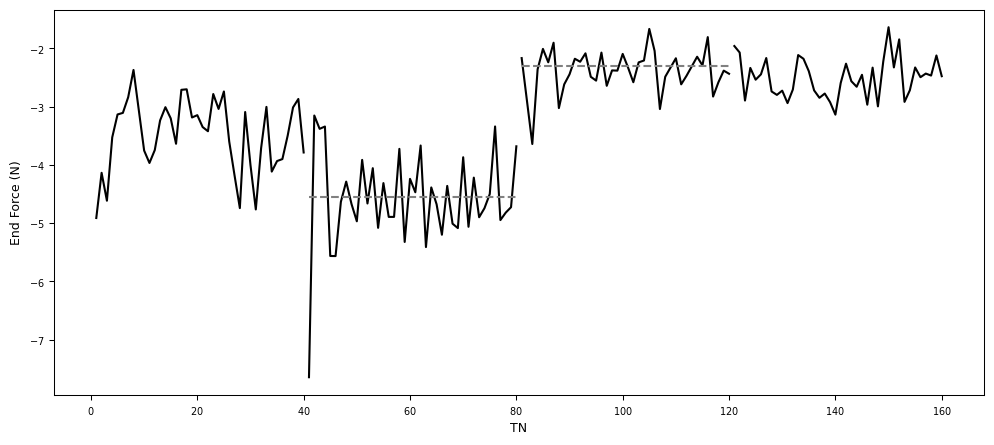

In [49]:
plt.figure(figsize=(12,5))
# sns.lineplot(data=subjs_correct, x='TotalTrialNum', y = 'endForce', hue='subNum', legend=False)
for bn, block_data in subjs_correct.groupby('BN'):
    target_force = block_data['targetForce'].iloc[0]
    gain = block_data['forceGain'].iloc[0]
    optimal_end_force = target_force / gain
    print(f"BN: {bn}, Target Force: {target_force}, Gain: {gain}")

    plt.plot(block_data['TotalTrialNum'], block_data['actualEndForce'], label=bn, color = 'black')
    start_trial = block_data['TotalTrialNum'].min()
    end_trial = block_data['TotalTrialNum'].max()
    if bn in [2, 3]:
        plt.hlines(optimal_end_force, start_trial, end_trial, colors='gray', linestyles='dashed')
plt.xlabel('TN')
plt.ylabel('End Force (N)')
plt.show()

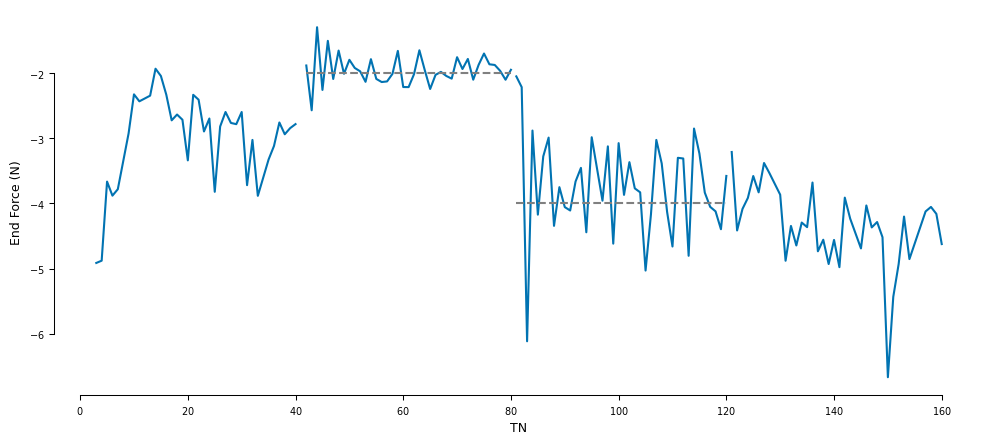

In [21]:
plt.figure(figsize=(12,5))
# sns.lineplot(data=subjs_correct, x='TotalTrialNum', y = 'endForce', hue='subNum', legend=False)
for bn, block_data in subjs_correct.groupby('BN'):
    sns.lineplot(data=block_data, x='TotalTrialNum', y = 'actualEndForce', label=bn, hue = 'subNum', legend=False, palette = 'colorblind')
    start_trial = block_data['TotalTrialNum'].min()
    end_trial = block_data['TotalTrialNum'].max()

    for sub_num, sub_data in block_data.groupby('subNum'):
        target_force = sub_data['targetForce'].iloc[0]
        gain = sub_data['forceGain'].iloc[0]
        optimal_end_force = target_force / gain

        if bn in [2, 3]:
            plt.hlines(optimal_end_force, start_trial, end_trial, colors='gray', linestyles='dashed')

    # if bn in [2, 3]:
    #     plt.hlines(optimal_end_force, start_trial, end_trial, colors='gray', linestyles='dashed')
plt.xlabel('TN')
plt.ylabel('End Force (N)')
sns.despine(trim = True)
plt.show()

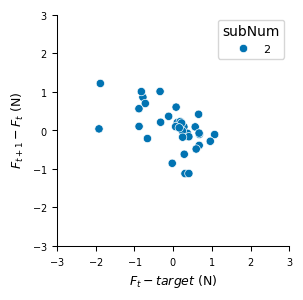

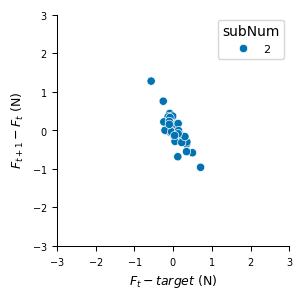

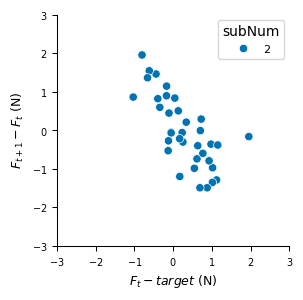

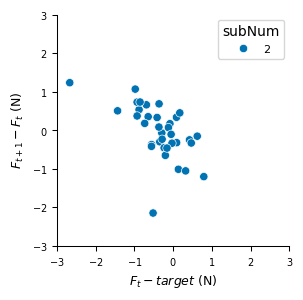

In [33]:
for bn, block_data in subjs_correct.groupby('BN'):

    # plot end_force_t+1 - end_force_t against error for each trial in the block
    plt.figure(figsize=(3,3))
    block_data = block_data.sort_values('TotalTrialNum')
    block_data['end_force_diff'] = block_data['actualEndForce'].diff().shift(-1)  # end_force_t+1 - end_force_t
    block_data['error'] = block_data['actualEndForce'] - block_data['targetForce'] / block_data['forceGain']
    sns.scatterplot(data=block_data, x='error', y='end_force_diff', hue='subNum', palette='colorblind')



    plt.xlabel(r'$F_{t} - target$ (N)')
    plt.ylabel(r'$F_{t+1} - F_{t}$ (N)')
    plt.xlim(-3, 3)
    plt.ylim(-3, 3)
    sns.despine(trim = True)